<a href="https://colab.research.google.com/github/vrundan7/carla-ml-safety/blob/main/calibration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/2026 (1)/2026"

import os
import csv
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_DIR = f"{BASE_PATH}/model_outputs"
LABELS = ['has_traffic_light', 'has_pedestrian', 'has_vehicle']

TEST_CSV = f"{BASE_PATH}/test/test/labels.csv"
TEST_IMG = f"{BASE_PATH}/test/test/rgb-front"
VAL_CSV  = f"{BASE_PATH}/validation/validation/labels.csv"
VAL_IMG  = f"{BASE_PATH}/validation/validation/rgb-front"

BATCH_SIZE = 32
print(f"Device: {DEVICE}")

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


Mounted at /content/drive
Device: cuda


Dataset + Model Helpers


In [ ]:

class DrivingDataset(Dataset):
    def __init__(self, csv_path, img_dir, label_col, transform=None):
        self.transform = transform
        self.samples = []
        with open(csv_path, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                frame = row['frame']
                label = 1.0 if row[label_col] == 'True' else 0.0
                img_path = os.path.join(img_dir, f"{frame}.jpg")
                if os.path.exists(img_path):
                    self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)

def load_model(label_col):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(512, 1)
    model.load_state_dict(torch.load(
        os.path.join(MODEL_DIR, f"best_{label_col}.pth"), map_location=DEVICE))
    model.to(DEVICE).eval()
    return model

def get_logits_and_labels(model, loader):
    all_logits, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(DEVICE)
            logits = model(imgs).squeeze()
            all_logits.extend(logits.cpu().numpy())
            all_labels.extend(lbls.numpy())
    return np.array(all_logits), np.array(all_labels)

nw = 2 if torch.cuda.is_available() else 0
print("✅ Helpers defined.")



✅ Helpers defined.


(Ex 7.4): Compute ECE + Reliability Diagrams


  Exercise 7.4: ECE — In-Distribution Test Set
  Traffic Light       : ECE = 0.0387
  Pedestrian          : ECE = 0.2255
  Vehicle             : ECE = 0.0706


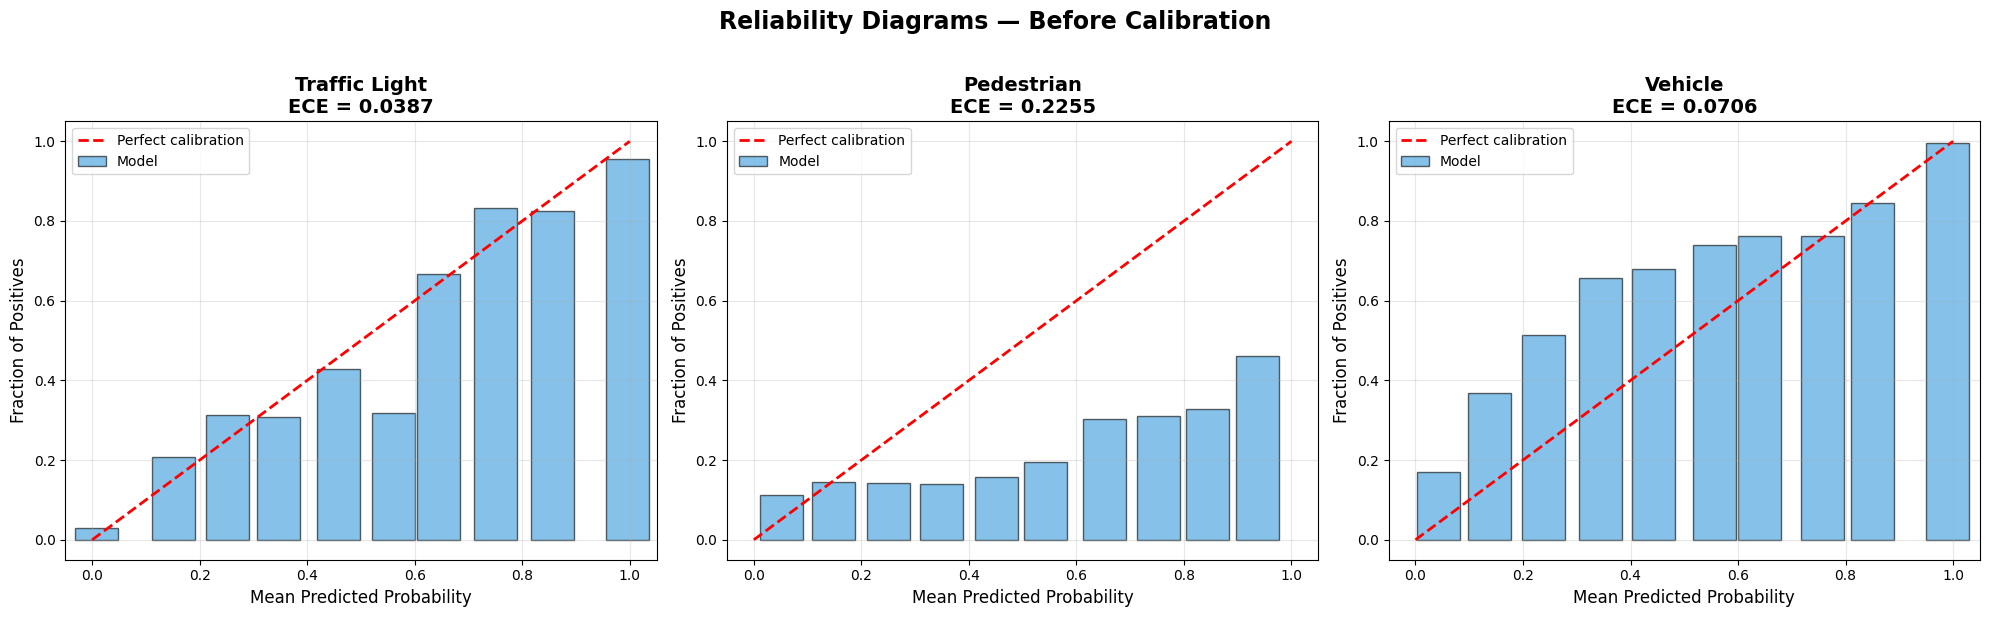

In [ ]:

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def compute_ece(probs, labels, n_bins=10):
    """
    Expected Calibration Error for binary classification.
    probs: predicted probabilities (after sigmoid)
    labels: ground truth (0 or 1)
    """
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_accs = []
    bin_confs = []
    bin_counts = []

    for i in range(n_bins):
        mask = (probs >= bin_edges[i]) & (probs < bin_edges[i + 1])
        count = mask.sum()
        if count > 0:
            avg_conf = probs[mask].mean()
            avg_acc = labels[mask].mean()
            ece += abs(avg_acc - avg_conf) * count
            bin_accs.append(avg_acc)
            bin_confs.append(avg_conf)
        else:
            bin_accs.append(0)
            bin_confs.append((bin_edges[i] + bin_edges[i+1]) / 2)
        bin_counts.append(count)

    ece /= len(probs)
    return ece, np.array(bin_accs), np.array(bin_confs), np.array(bin_counts)


# Collect logits for all 3 models on in-distribution test set
model_data = {}  # {label: {'logits', 'labels', 'probs'}}

for label_col in LABELS:
    model = load_model(label_col)
    test_ds = DrivingDataset(TEST_CSV, TEST_IMG, label_col, test_transform)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=nw, pin_memory=torch.cuda.is_available())

    logits, labels = get_logits_and_labels(model, test_loader)
    probs = sigmoid(logits)

    model_data[label_col] = {
        'logits': logits, 'labels': labels, 'probs': probs, 'model': model
    }

# Compute ECE and plot reliability diagrams
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

print("\n" + "="*60)
print("  Exercise 7.4: ECE — In-Distribution Test Set")
print("="*60)

ece_results = {}

for idx, label_col in enumerate(LABELS):
    d = model_data[label_col]
    ece, bin_accs, bin_confs, bin_counts = compute_ece(d['probs'], d['labels'])
    ece_results[label_col] = ece

    tag = label_col.replace('has_','').replace('_',' ').title()
    print(f"  {tag:<20}: ECE = {ece:.4f}")

    ax = axes[idx]
    ax.bar(bin_confs, bin_accs, width=0.08, alpha=0.6, color='#3498db',
           edgecolor='black', label='Model')
    ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect calibration')
    ax.set_title(f'{tag}\nECE = {ece:.4f}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Mean Predicted Probability', fontsize=12)
    ax.set_ylabel('Fraction of Positives', fontsize=12)
    ax.legend(fontsize=10)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

print("="*60)

plt.suptitle('Reliability Diagrams — Before Calibration',
             fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/reliability_before.png", dpi=150, bbox_inches='tight')
plt.show()


(Ex 7.5): Temperature Scaling — Optimize T on Validation Set


  Exercise 7.5: Temperature Scaling — Optimal T
  Traffic Light       : Optimal T = 1.3  (NLL = 0.0616)
  Pedestrian          : Optimal T = 1.9  (NLL = 0.6184)
  Vehicle             : Optimal T = 1.4  (NLL = 0.2656)


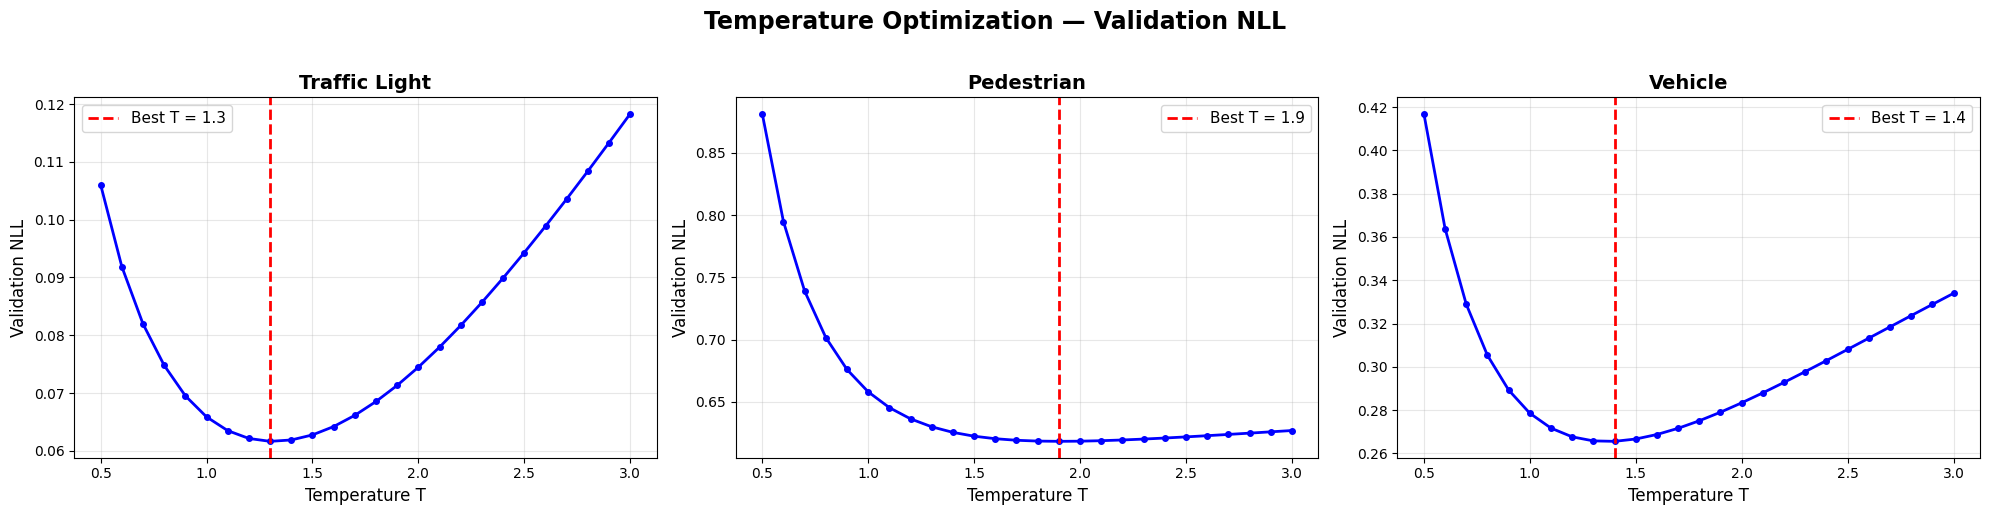

In [ ]:

# Collect validation logits
val_data = {}
for label_col in LABELS:
    model = model_data[label_col]['model']
    val_ds = DrivingDataset(VAL_CSV, VAL_IMG, label_col, test_transform)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=nw, pin_memory=torch.cuda.is_available())
    logits, labels = get_logits_and_labels(model, val_loader)
    val_data[label_col] = {'logits': logits, 'labels': labels}


def compute_nll(logits, labels, T):
    """Negative log-likelihood with temperature scaling: p = sigmoid(z/T)"""
    probs = sigmoid(logits / T)
    # Clip to avoid log(0)
    probs = np.clip(probs, 1e-7, 1 - 1e-7)
    nll = -np.mean(labels * np.log(probs) + (1 - labels) * np.log(1 - probs))
    return nll


# Grid search for optimal T
T_grid = np.arange(0.5, 3.05, 0.1)

print("\n" + "="*60)
print("  Exercise 7.5: Temperature Scaling — Optimal T")
print("="*60)

optimal_T = {}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for idx, label_col in enumerate(LABELS):
    vd = val_data[label_col]
    nlls = [compute_nll(vd['logits'], vd['labels'], T) for T in T_grid]

    best_idx = np.argmin(nlls)
    best_T = T_grid[best_idx]
    optimal_T[label_col] = best_T

    tag = label_col.replace('has_','').replace('_',' ').title()
    print(f"  {tag:<20}: Optimal T = {best_T:.1f}  (NLL = {nlls[best_idx]:.4f})")

    ax = axes[idx]
    ax.plot(T_grid, nlls, 'b-o', markersize=4, linewidth=2)
    ax.axvline(x=best_T, color='red', linestyle='--', linewidth=2,
               label=f'Best T = {best_T:.1f}')
    ax.set_xlabel('Temperature T', fontsize=12)
    ax.set_ylabel('Validation NLL', fontsize=12)
    ax.set_title(f'{tag}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

print("="*60)

plt.suptitle('Temperature Optimization — Validation NLL',
             fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/temperature_optimization.png", dpi=150, bbox_inches='tight')
plt.show()



(Ex 7.5): ECE Before vs After Temperature Scaling


  ECE Before vs After Temperature Scaling

Model                  ECE Before      ECE After       Optimal T    Improvement    
----------------------------------------------------------------------
Traffic Light          0.0387          0.0350          1.3          0.0037++++++++
Pedestrian             0.2255          0.2410          1.9          -0.0155+++++++
Vehicle                0.0706          0.0669          1.4          0.0037++++++++


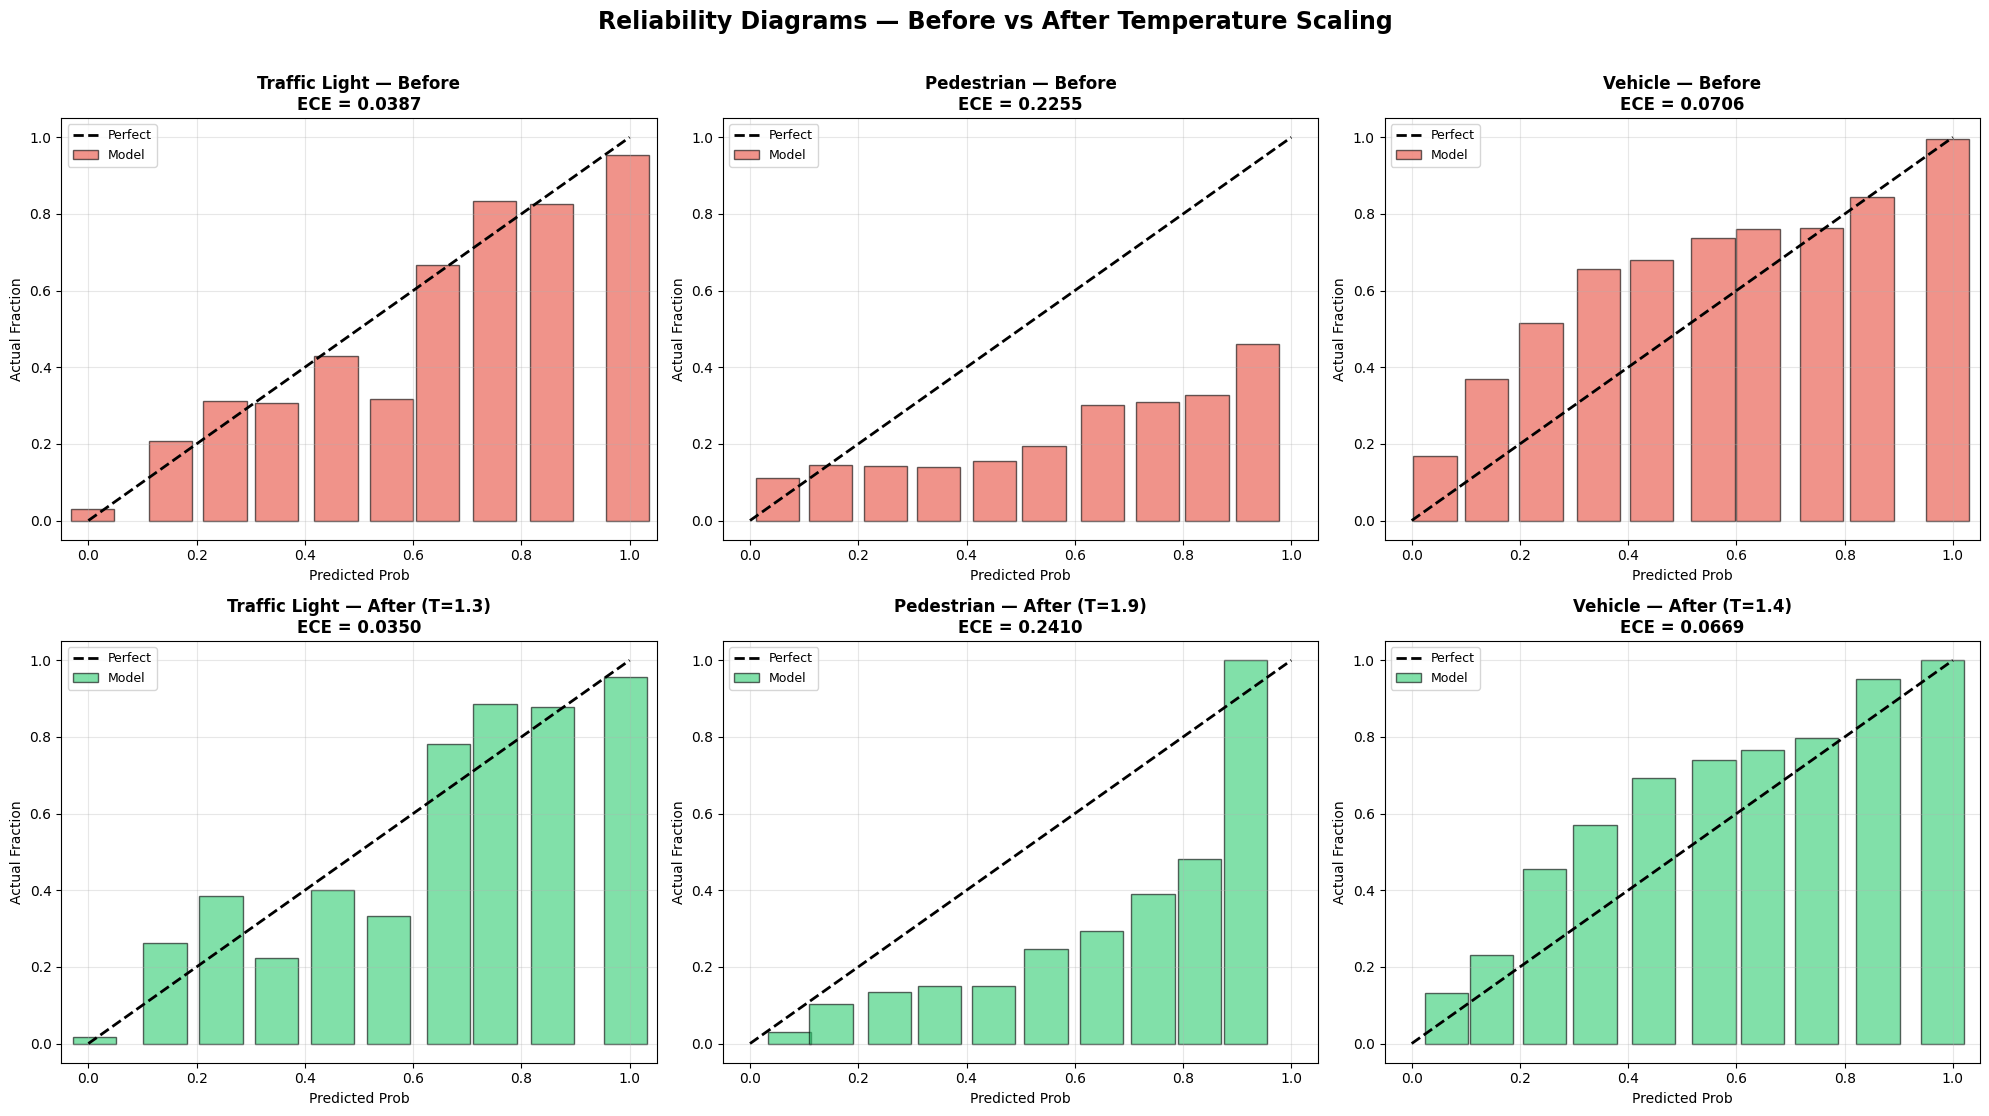

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(20, 11))

print("\n" + "="*70)
print("  ECE Before vs After Temperature Scaling")
print("="*70)
print(f"\n{'Model':<22} {'ECE Before':<15} {'ECE After':<15} {'Optimal T':<12} {'Improvement':<15}")
print("-"*70)

ece_after = {}

for idx, label_col in enumerate(LABELS):
    d = model_data[label_col]
    T = optimal_T[label_col]
    tag = label_col.replace('has_','').replace('_',' ').title()

    # Before
    ece_before, bin_accs_b, bin_confs_b, _ = compute_ece(d['probs'], d['labels'])

    # After
    probs_scaled = sigmoid(d['logits'] / T)
    ece_a, bin_accs_a, bin_confs_a, _ = compute_ece(probs_scaled, d['labels'])
    ece_after[label_col] = ece_a

    improvement = ece_before - ece_a
    print(f"{tag:<22} {ece_before:<15.4f} {ece_a:<15.4f} {T:<12.1f} {improvement:+<14.4f}")

    # Row 0: Before
    ax = axes[0, idx]
    ax.bar(bin_confs_b, bin_accs_b, width=0.08, alpha=0.6, color='#e74c3c',
           edgecolor='black', label='Model')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect')
    ax.set_title(f'{tag} — Before\nECE = {ece_before:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Prob', fontsize=10)
    ax.set_ylabel('Actual Fraction', fontsize=10)
    ax.legend(fontsize=9)
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

    # Row 1: After
    ax = axes[1, idx]
    ax.bar(bin_confs_a, bin_accs_a, width=0.08, alpha=0.6, color='#2ecc71',
           edgecolor='black', label='Model')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect')
    ax.set_title(f'{tag} — After (T={T:.1f})\nECE = {ece_a:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Prob', fontsize=10)
    ax.set_ylabel('Actual Fraction', fontsize=10)
    ax.legend(fontsize=9)
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

print("="*70)

plt.suptitle('Reliability Diagrams — Before vs After Temperature Scaling',
             fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/reliability_before_after.png", dpi=150, bbox_inches='tight')
plt.show()



(Ex 7.6): Cost-Optimal Decision — 2×2 Table


  Exercise 7.6: Cost-Optimal Decision (C_FN=100, C_FP=1)
  Pedestrian Model — In-Distribution Test Set

                                            τ = 0.5      τ = τ* = 0.0099
--------------------------------------------------------------------------------
Uncalibrated                   L = 32624            L = 2869            
                               FN=317   FP=924      FN=0     FP=2869    

Calibrated (T-scaled)          L = 32624            L = 2894            
                               FN=317   FP=924      FN=0     FP=2894    

  ★ Lowest total loss: Uncalibrated + τ = τ* = 0.0099  →  L = 2869


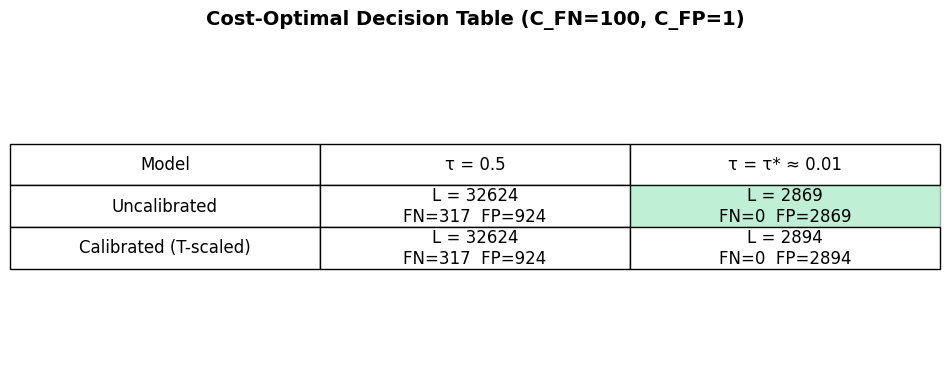

In [ ]:

C_FN = 100   # cost of false negative
C_FP = 1     # cost of false positive
TAU_DEFAULT = 0.5
TAU_STAR = 0.0099  # cost-optimal threshold ≈ C_FP / (C_FP + C_FN)

label_col = 'has_pedestrian'
d = model_data[label_col]
T = optimal_T[label_col]

probs_uncal = d['probs']                     # uncalibrated
probs_cal = sigmoid(d['logits'] / T)          # temperature-scaled
labels = d['labels']

def compute_cost(probs, labels, threshold, c_fn, c_fp):
    preds = (probs >= threshold).astype(float)
    fn = int(((preds == 0) & (labels == 1)).sum())
    fp = int(((preds == 1) & (labels == 0)).sum())
    tp = int(((preds == 1) & (labels == 1)).sum())
    tn = int(((preds == 0) & (labels == 0)).sum())
    total_loss = c_fn * fn + c_fp * fp
    return total_loss, fn, fp, tp, tn

# Compute 2×2
results_table = {}
for cal_name, probs in [("Uncalibrated", probs_uncal), ("Calibrated (T-scaled)", probs_cal)]:
    for tau_name, tau in [(f"τ = 0.5", TAU_DEFAULT), (f"τ = τ* = {TAU_STAR}", TAU_STAR)]:
        loss, fn, fp, tp, tn = compute_cost(probs, labels, tau, C_FN, C_FP)
        results_table[(cal_name, tau_name)] = {
            'loss': loss, 'fn': fn, 'fp': fp, 'tp': tp, 'tn': tn
        }

print("\n" + "="*80)
print(f"  Exercise 7.6: Cost-Optimal Decision (C_FN={C_FN}, C_FP={C_FP})")
print(f"  Pedestrian Model — In-Distribution Test Set")
print("="*80)

print(f"\n{'':30} {'τ = 0.5':>20} {'τ = τ* = 0.0099':>20}")
print("-"*80)

for cal_name in ["Uncalibrated", "Calibrated (T-scaled)"]:
    r1 = results_table[(cal_name, "τ = 0.5")]
    r2 = results_table[(cal_name, f"τ = τ* = {TAU_STAR}")]
    print(f"{cal_name:<30} L = {r1['loss']:<16} L = {r2['loss']:<16}")
    print(f"{'':30} FN={r1['fn']:<5} FP={r1['fp']:<8} FN={r2['fn']:<5} FP={r2['fp']:<8}")
    print()

# Find best
best_key = min(results_table.keys(), key=lambda k: results_table[k]['loss'])
best_loss = results_table[best_key]['loss']
print(f"  ★ Lowest total loss: {best_key[0]} + {best_key[1]}  →  L = {best_loss}")
print("="*80)

# Visual table
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table_data = []
for cal_name in ["Uncalibrated", "Calibrated (T-scaled)"]:
    row = [cal_name]
    for tau_name in ["τ = 0.5", f"τ = τ* = {TAU_STAR}"]:
        r = results_table[(cal_name, tau_name)]
        row.append(f"L = {r['loss']}\nFN={r['fn']}  FP={r['fp']}")
    table_data.append(row)

table = ax.table(cellText=table_data,
                  colLabels=["Model", "τ = 0.5", f"τ = τ* ≈ 0.01"],
                  loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2.5)

# Highlight best cell
for key, cell in table.get_celld().items():
    if key[0] > 0:  # data rows
        cal_name = ["Uncalibrated", "Calibrated (T-scaled)"][key[0]-1]
        tau_name = ["τ = 0.5", f"τ = τ* = {TAU_STAR}"][key[1]-1] if key[1] > 0 else ""
        if key[1] > 0 and (cal_name, tau_name) == best_key:
            cell.set_facecolor('#2ecc71')
            cell.set_alpha(0.3)

plt.title('Cost-Optimal Decision Table (C_FN=100, C_FP=1)',
          fontsize=14, fontweight='bold', pad=20)
plt.savefig(f"{MODEL_DIR}/cost_optimal_table.png", dpi=150, bbox_inches='tight')
plt.show()
